<a href="https://colab.research.google.com/github/Fazna-kozhipparambil/breast_cancer_detection_classification/blob/main/Breast_cancer_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Breast Cancer Detection using Machine Learning**




1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ( accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score )

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingClassifier
import joblib

2. Load Dataset

In [2]:
from google.colab import files

In [8]:
files.upload()
!mkdir -p ~/.kaggle !cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data

!unzip -o breast-cancer-wisconsin-data.zip


chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
breast-cancer-wisconsin-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  breast-cancer-wisconsin-data.zip
  inflating: data.csv                


In [10]:
df = pd.read_csv("data.csv")

print(df.shape)

df.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


3. Data Cleaning

In [11]:
df.drop(['id','Unnamed: 32'], axis=1, inplace=True)

In [12]:
df['diagnosis'] = df['diagnosis'].map({ 'M':1, 'B':0 })

In [13]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

4. Exploratory Data Analysis

  Target Distribution

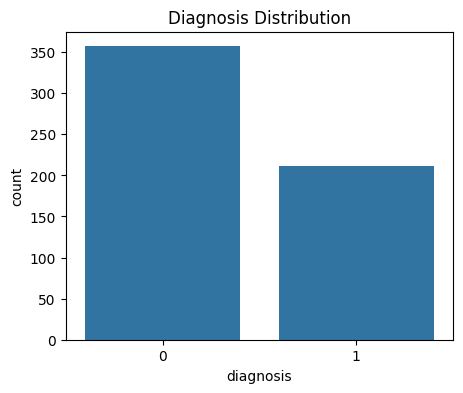

In [15]:
plt.figure(figsize=(5,4))
sns.countplot(x='diagnosis', data=df)
plt.title("Diagnosis Distribution")
plt.show()

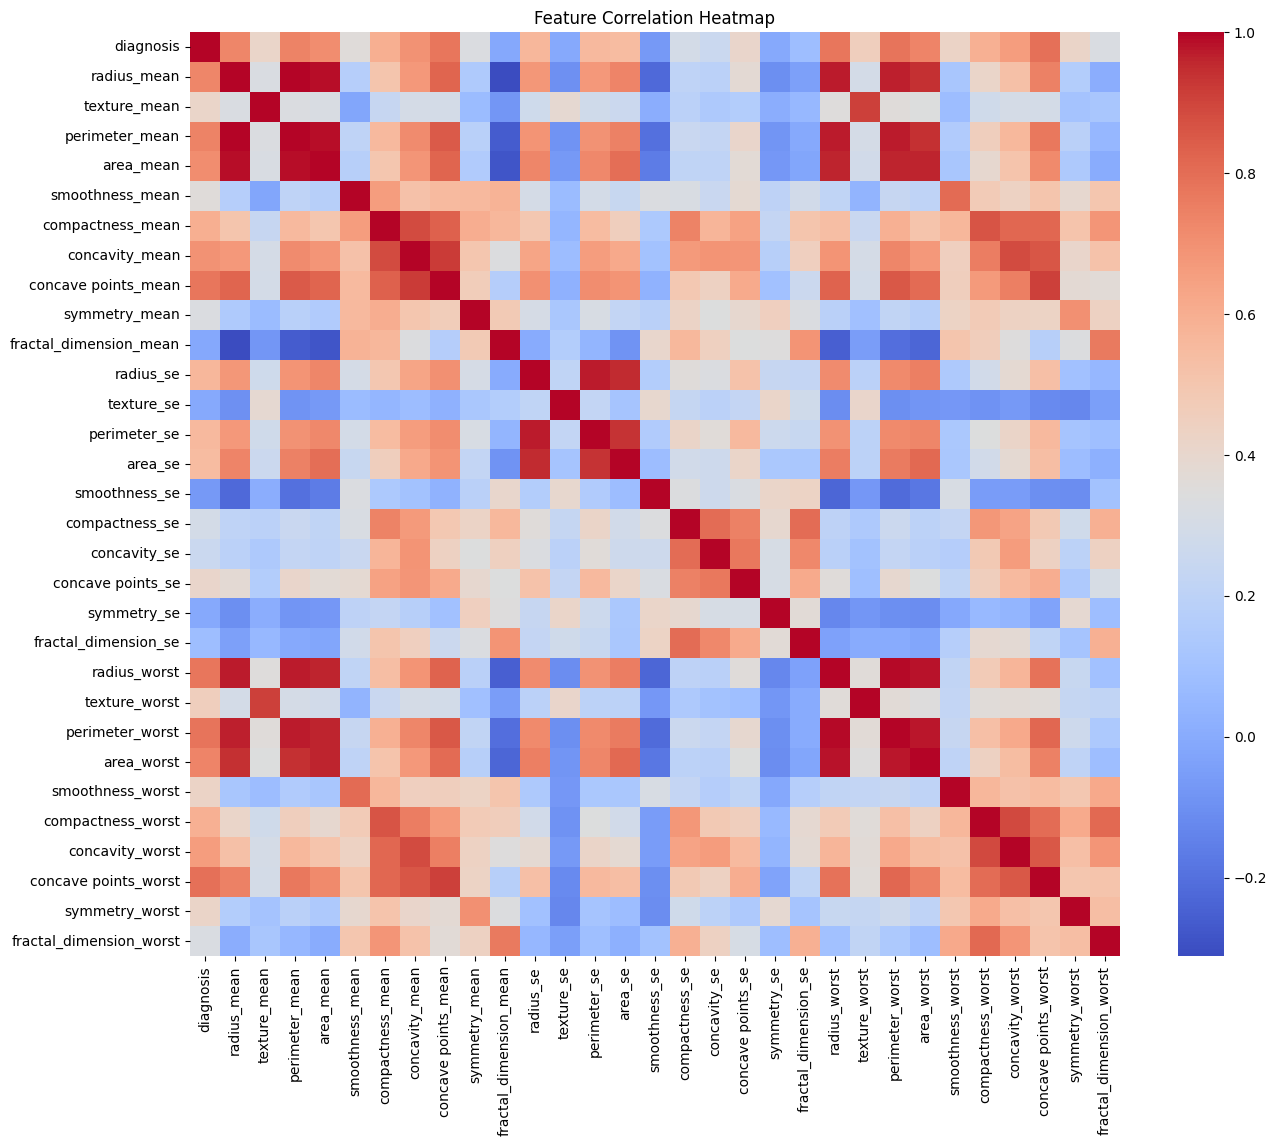

In [16]:
#Correlation Heatmap
plt.figure(figsize=(15,12))
sns.heatmap( df.corr(), cmap='coolwarm' )
plt.title("Feature Correlation Heatmap")
plt.show()

**5. Feature & Target Split**

In [18]:

X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

**6. Train Test Split**

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (455, 30)
Test Shape: (114, 30)


**7. Random Forest Model**

In [21]:
rf = RandomForestClassifier( n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, random_state=42 )
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

Evaluation

In [22]:
print( "Random Forest Accuracy:", accuracy_score(y_test,y_pred_rf) )
print( classification_report( y_test, y_pred_rf, target_names=['Benign','Malignant'] ) )

Random Forest Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



**8. Confusion Matrix**

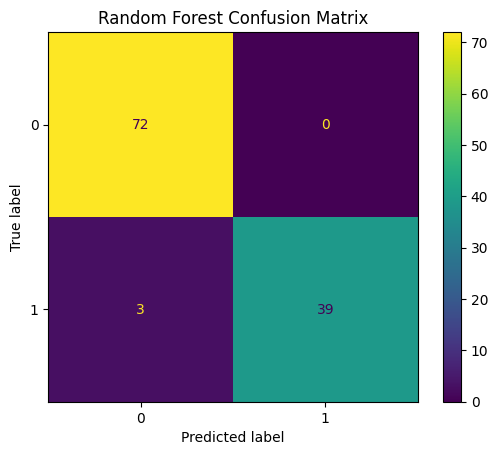

In [23]:

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

**9. ROC Curve**

AUC Score: 0.9943783068783069


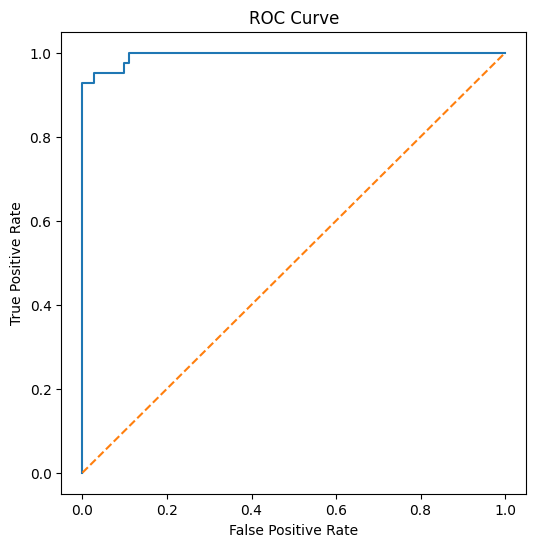

In [25]:
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve( y_test, y_prob_rf )
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
print( "AUC Score:", roc_auc_score( y_test, y_prob_rf ) )
plt.show()

**10. Feature Importance**

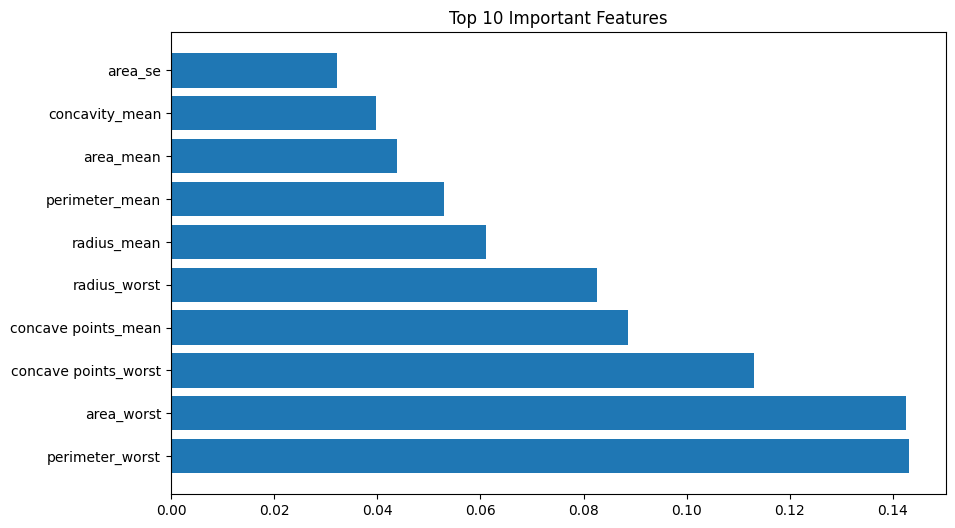

,Feature,Importance
22,perimeter_worst,0.143121
23,area_worst,0.142449
27,concave points_worst,0.112978
7,concave points_mean,0.088663
20,radius_worst,0.082649
0,radius_mean,0.061043
2,perimeter_mean,0.052928
3,area_mean,0.043820
6,concavity_mean,0.039761
13,area_se,0.032237


In [29]:

feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.title("Top 10 Important Features")
plt.show()
feature_importance.head(10)


**11. Cross Validation**

In [31]:
scores = cross_val_score( rf, X, y, cv=5, scoring='accuracy' )
print("Cross Validation Scores:")
print(scores)
print( "Average Accuracy:", scores.mean())

Cross Validation Scores:
[0.92982456 0.93859649 0.99122807 0.97368421 0.97345133]
Average Accuracy: 0.9613569321533924


**12. XGBoost Model**

In [32]:
!pip install -q xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train,y_train)
y_pred_xgb = xgb.predict(X_test)

Evaluation

In [33]:
print( "XGBoost Accuracy:", accuracy_score( y_test, y_pred_xgb ) )
print( classification_report( y_test, y_pred_xgb, target_names=['Benign','Malignant'] ) )

XGBoost Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



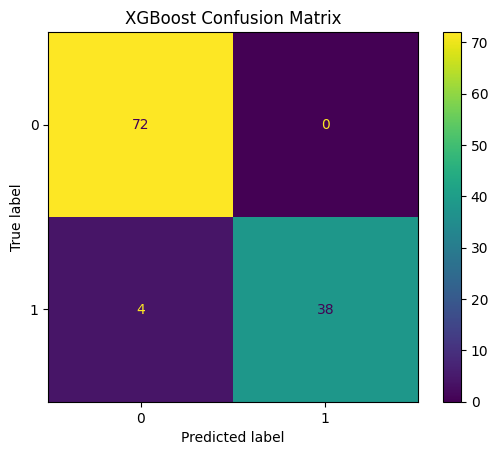

In [34]:
#Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test,
    y_test
)

plt.title("XGBoost Confusion Matrix")

plt.show()

**13. Gradient Boosting**

In [35]:
gbc = GradientBoostingClassifier( n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42 )
gbc.fit(X_train,y_train)
y_pred_gbc = gbc.predict(X_test)
print( "Gradient Boosting Accuracy:", accuracy_score( y_test, y_pred_gbc ) )
print( classification_report( y_test, y_pred_gbc, target_names=['Benign','Malignant'] ) )

Gradient Boosting Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



**14. Compare Models**

In [37]:
results = pd.DataFrame({ 'Model':[ 'Random Forest', 'Gradient Boosting', 'XGBoost' ],
                        'Accuracy':[ accuracy_score(y_test,y_pred_rf), accuracy_score(y_test,y_pred_gbc), accuracy_score(y_test,y_pred_xgb) ] })
results.sort_values( by='Accuracy', ascending=False )

,Model,Accuracy
0,Random Forest,0.973684
1,Gradient Boosting,0.964912
2,XGBoost,0.964912


**15. Save Best Model**

In [38]:

joblib.dump(
    xgb,
    'breast_cancer_model.pkl'
)

print("Model saved successfully")

Model saved successfully


**Conclusion**


* Random Forest, Gradient Boosting and XGBoost were trained and evaluated.
* Feature importance analysis identified the strongest predictors.
* ROC-AUC was used to assess classification quality.
* Cross-validation was performed for robust evaluation.
* The best model was saved for future deployment.